In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Load data
data = pd.read_csv("kmeans_data.csv")
data

,age,annual_income,annual_spending_score,true_segment
0,59.6,123358.02,8.55,2
1,54.9,111665.14,8.46,2
2,20.3,19495.56,2.53,0
3,26.3,20434.57,0.73,0
4,18.0,21971.84,2.26,0
...,...,...,...,...
1495,51.8,122959.93,7.32,2
1496,57.8,112264.88,8.79,2
1497,41.9,50392.46,4.64,1
1498,54.0,102060.33,8.12,2


In [3]:
data.shape

(1500, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1500 non-null   float64
 1   annual_income          1500 non-null   float64
 2   annual_spending_score  1500 non-null   float64
 3   true_segment           1500 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 47.0 KB


In [5]:
data.isnull().sum()

age                      0
annual_income            0
annual_spending_score    0
true_segment             0
dtype: int64

<Axes: xlabel='annual_income', ylabel='annual_spending_score'>

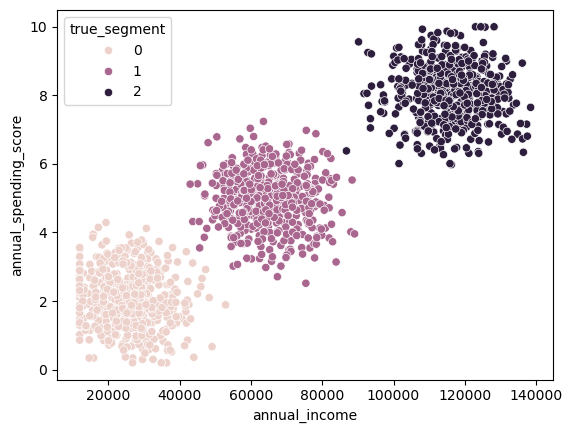

In [9]:
sns.scatterplot(x="annual_income",y="annual_spending_score",data=data,hue="true_segment")

In [10]:
data.head()

,age,annual_income,annual_spending_score,true_segment
0,59.6,123358.02,8.55,2
1,54.9,111665.14,8.46,2
2,20.3,19495.56,2.53,0
3,26.3,20434.57,0.73,0
4,18.0,21971.84,2.26,0


In [13]:
# Perfome kmeans
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(data)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
model.inertia_

111480295122.2427

In [19]:
# Elbow method
wcss = []
for i in range(1,20):
    model = KMeans(n_clusters=i)
    model.fit(data)
    wcss.append(model.inertia_)
wcss

[2175899450789.462,
 489784311903.89734,
 111480295122.2427,
 85109631381.20592,
 62347010519.01036,
 38070896067.14567,
 31007124721.32566,
 25418703533.665253,
 18567611664.69931,
 15544712231.295048,
 13136380328.880365,
 12037512478.537292,
 9312271121.272179,
 9072455976.808752,
 8019367396.552001,
 6373720244.201445,
 5737242776.204385,
 4902167516.895453,
 4878910866.726985]

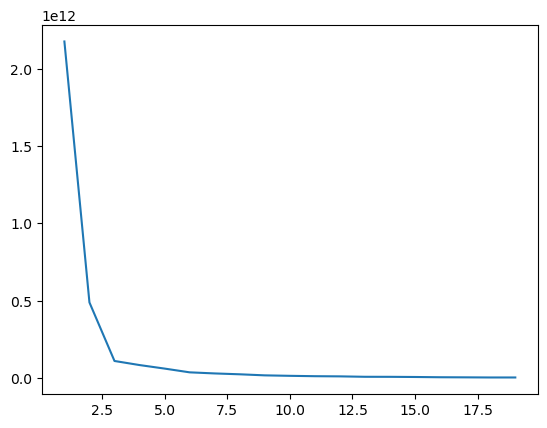

In [20]:
plt.plot(range(1,20),wcss)

In [22]:
model = KMeans(n_clusters=1500)
model.fit(data)
model.inertia_

0.0

In [25]:
# Silhout
model = KMeans(n_clusters=3)
model.fit(data[["annual_income","annual_spending_score"]])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [28]:
model.cluster_centers_

array([[1.16299153e+05, 8.07588353e+00],
       [2.53862536e+04, 2.05975758e+00],
       [6.48536015e+04, 4.95433925e+00]])